1.Import Libraries

In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt

2.Load Datasets

In [4]:
trads = pd.read_csv('historical_data.csv')

In [9]:
trads.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [10]:
fear_greed = pd.read_csv('fear_greed_index.csv')

In [12]:
fear_greed.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


3.Data Cleaning & Preparation

In [13]:
fear_greed['date'] = pd.to_datetime(fear_greed['date'])

In [14]:
trads['date'] = pd.to_datetime(trads['Timestamp IST'], dayfirst=True).dt.date

In [15]:
trads['date'] = pd.to_datetime(trads['date'])

4.Aggregate Tread Performance

In [16]:
daily_pnl = trads.groupby('date')['Closed PnL'].sum().reset_index()

5. Merge with Sentiment Data

In [17]:
merged = pd.merge(
    daily_pnl,
    fear_greed[['date','classification']], 
    on='date', 
    how='inner'
)

In [22]:
summary = merged.groupby('classification')['Closed PnL'].agg(
    count='count', 
    avg_pnl='mean', 
    total_pnl='sum'
).reset_index()

print("\n summary by Sentiment:\n")
print(summary)


 summary by Sentiment:

  classification  count       avg_pnl     total_pnl
0   Extreme Fear     14  52793.589178  7.391102e+05
1  Extreme Greed    114  23817.292199  2.715171e+06
2           Fear     91  36891.818040  3.357155e+06
3          Greed    193  11140.566181  2.150129e+06
4        Neutral     67  19297.323516  1.292921e+06


6. Analysis: Performance by Sentiment

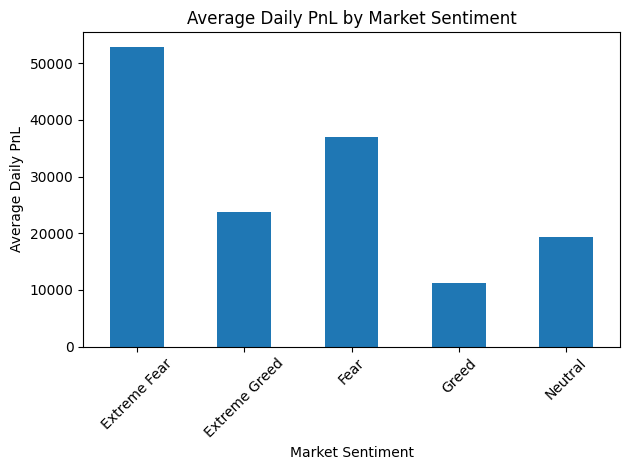

In [25]:
plt.figure()
summary.set_index('classification')['avg_pnl'].plot(kind='bar')
plt.title("Average Daily PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Daily PnL")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



In [26]:
summary.to_csv("Sentiment_analysis_output.csv", index=False)